# Clustering Analysis

#### 1. Apply clustering techniques (e.g., K-Means, Hierarchical Clustering).

#### 2. Identify meaningful groupings such as:
      - Customer Segments 
      - Demand Patterns
       
#### 3. Interpret clustering results and discuss business implications.



In [362]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [363]:
# Load the Dataset
df = pd.read_csv('../data/cleaned_retail_data.csv')

# Shape of dataset
print(df.shape)

df.head()


(333234, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34



#### Retail transaction data is commonly used for clustering, especially for customer segmentation.
#### For this first we need to transform the raw dataset into customer-level features. 

## Customer Segmentation (RFM Clustering)
Group the data by Customer ID and calculate RFM metrics.

### RFM Features

* Recency (R) - How recently a customer purchased
* Frequency (F) - How many purchases the customer made
* Monetary (M) - How much money the customer spent

### Step by step clustering workflow:
1. Assess and clean the dataset (df) by identifying common data quality issues and preparing it for analysis.

In [364]:
# Data Cleaning - ckeck

# Remove missing values
print("Number of missing values")
print(df.isna().sum())

# Remove duplicates
print(f"Number of duplicates: {df.duplicated().sum()}")

# Handle incorrect values (Example: Negative quantities , Invalid prices)
print(f"Negative quantities: {(df[["Quantity"]] < 0).sum()}")
print(f"Negative prices: {(df[["Price"]] < 0).sum()}")

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"InvoiceDate data type: {df['InvoiceDate'].dtype}")


Number of missing values
Invoice          0
StockCode        0
Description      0
Quantity         0
InvoiceDate      0
Price            0
Customer ID      0
Country          0
Total_Revenue    0
dtype: int64
Number of duplicates: 0
Negative quantities: Quantity    0
dtype: int64
Negative prices: Price    0
dtype: int64
InvoiceDate data type: datetime64[ns]


2. Transform the cleaned dataset by grouping the data by ‘Customer ID’ and computing the RFM (Recency, Frequency, Monetary) metrics.


In [365]:
# Feature Engineering - Calculate RFM metrics

# Recency = (reference date) − (last purchase date)

# reference date (usually max(most recent) date in dataset)
reference_date = df["InvoiceDate"].max()
print(reference_date)
# get last purchase per customer
last_purchase = df.groupby("Customer ID")["InvoiceDate"].max()

# Recency (in days)
recency = (reference_date - last_purchase).dt.days

# Frequency
frequency = df.groupby("Customer ID")["Invoice"].nunique()

# Monetary
monetary = df.groupby("Customer ID")["Total_Revenue"].sum()

# Combine them:
rfm = pd.concat([recency, frequency, monetary], axis=1)
rfm.columns = ["Recency","Frequency","Monetary"]
print(rfm.head())

# These features are widely used in customer segmentation.

2011-12-09 12:50:00
             Recency  Frequency  Monetary
Customer ID                              
12347.0            1          7   3314.73
12348.0          248          3     90.20
12349.0           18          1    999.15
12350.0          309          1    294.40
12352.0           35          7   1130.94


3. Standardize (scale) the numerical features in the rfm dataset so they are on the same scale for analysis or modeling.


In [366]:
# Feature Scaling - Use Standardization.
# Now features have: mean = 0 , standard deviation = 1

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(rfm)

rfm_scaled = rfm.copy()
rfm_scaled[["Recency","Frequency","Monetary"]] = scaled_data
print(rfm_scaled)


              Recency  Frequency  Monetary
Customer ID                               
12347.0     -0.905868   0.425524  1.040421
12348.0      1.566687  -0.144653 -0.425325
12349.0     -0.735692  -0.429742 -0.012152
12350.0      2.177318  -0.429742 -0.332504
12352.0     -0.565516   0.425524  0.047755
...               ...        ...       ...
18280.0      1.856987  -0.429742 -0.404052
18281.0      0.885984  -0.429742 -0.444999
18282.0     -0.845806  -0.287198 -0.414902
18283.0     -0.885847   1.708424  0.443991
18287.0     -0.495444  -0.144653 -0.029602

[4191 rows x 3 columns]


4. Determine the optimal number of clusters for grouping the data using the Elbow Method and Silhouette Score.

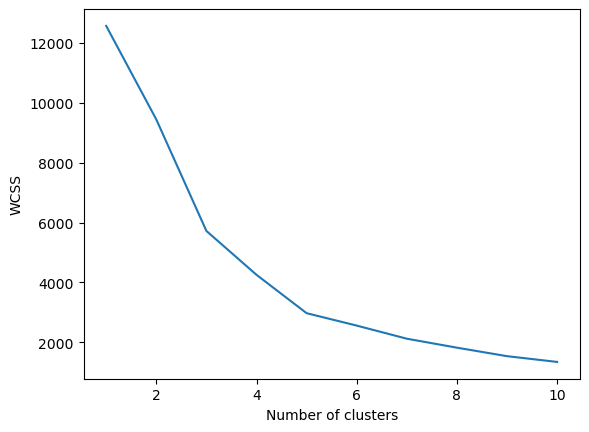

In [367]:
# Determine Optimal Number of Clusters
# Method : Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()


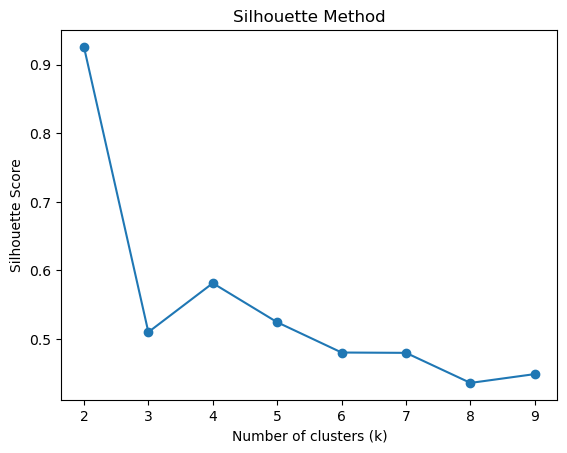

In [368]:
# Silhouette score (to justify the choice)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X = rfm_scaled  # your scaled RFM data

silhouette_scores = []

k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Plot
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()


Mathematically, choosing 2 clusters yields the most compact and well-separated groups. However, for business analysis, selecting a higher number of clusters can provide more meaningful insights. Therefore, we chose 4 clusters to ensure the segments are actionable and better reflect the diversity of customer behavior.

5. Apply K-Means clustering to segment the customers and assign each one to a cluster.


In [369]:
# Train the Clustering Model - K-Means

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(rfm_scaled)

rfm['Cluster'] = clusters
rfm

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12347.0,1,7,3314.73,0
12348.0,248,3,90.20,3
12349.0,18,1,999.15,0
12350.0,309,1,294.40,3
12352.0,35,7,1130.94,0
...,...,...,...,...
18280.0,277,1,137.00,3
18281.0,180,1,46.92,3
18282.0,7,2,113.13,0


6. Reduce the dimensionality of the dataset and visualize customer clusters in a 2D space.

(4191, 2)


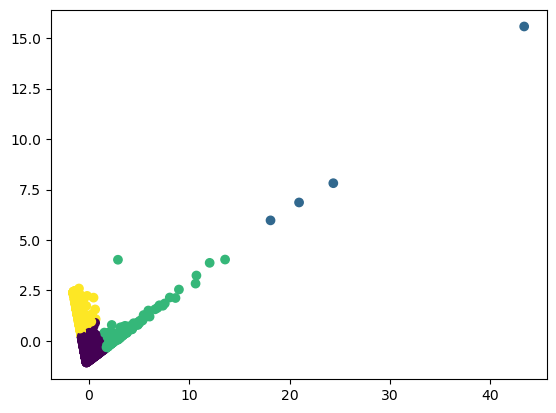

In [370]:
# Cluster Visualization
# Using PCA (dimensionality reduction)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)
print(rfm_pca.shape)
      
plt.scatter(rfm_pca[:,0], rfm_pca[:,1], c=rfm["Cluster"])
plt.show()


7. analyze and interpret each cluster by summarizing its key characteristics.

In [371]:
# Cluster Profiling (Most Important Step)
# Understand what each cluster represents.

cluster_profile = rfm.groupby('Cluster').mean()
print(cluster_profile)

            Recency   Frequency      Monetary
Cluster                                      
0         42.755903    3.413542    837.452623
1          1.000000  148.000000  43518.310000
2         12.379310   18.444444   5327.811762
3        245.770554    1.519120    308.776789


- Cluster 1 — “VIP / Best Customers”
- Cluster 2 — “Loyal / High-Value Customers”
- Cluster 0 — “Regular Customers”
- Cluster 3 — “Lost / Inactive Customers”

#
## Demand Pattern Analysis
We cluster products (items) based on their demand patterns to gain a deeper understanding of how different items perform in terms of sales. To measure demand, we apply an adapted version of the RFM (Recency, Frequency, Monetary) framework at the product level rather than the customer level.


In [372]:
# Feature Engineering - 

# Recency = (reference date) − (last purchase date)

# reference date (usually max date in dataset)
reference_date = df["InvoiceDate"].max()
print(reference_date)
# get last purchase per customer
last_purchase = df.groupby("Description")["InvoiceDate"].max()

# Recency (in days)
product_recency = (reference_date - last_purchase).dt.days

# Frequency
product_frequency = df.groupby("Description")["Quantity"].nunique()

# Monetary
product_monetary = df.groupby("Description")["Total_Revenue"].sum()

# Combine them:
rfm_product = pd.concat([product_recency, product_frequency, product_monetary], axis=1)
rfm_product.columns = ["Recency","Frequency","Monetary"]
print(rfm_product)

# These features are widely used in customer segmentation.

2011-12-09 12:50:00
                                  Recency  Frequency  Monetary
Description                                                   
 4 PURPLE FLOCK DINNER CANDLES          1          6    265.66
 50'S CHRISTMAS GIFT BAG LARGE          0         11   1601.25
 DOLLY GIRL BEAKER                      0          9   1182.50
 I LOVE LONDON MINI BACKPACK            1          8    908.85
 I LOVE LONDON MINI RUCKSACK           64          1      4.15
...                                   ...        ...       ...
ZINC T-LIGHT HOLDER STARS LARGE       144          1     22.80
ZINC T-LIGHT HOLDER STARS SMALL         0         11   2248.70
ZINC WILLIE WINKIE  CANDLE STICK        0         11   1726.22
ZINC WIRE KITCHEN ORGANISER             0          3     63.20
ZINC WIRE SWEETHEART LETTER TRAY        2          8    253.24

[3575 rows x 3 columns]


##### - Standardize (scale) the numerical features in the rfm dataset so they are on the same scale for analysis or modeling. 

In [373]:
# Feature Scaling - Use Standardization.
# Now features have: mean = 0 , standard deviation = 1

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_product_scaled = rfm_product.copy()
rfm_product_scaled[["Recency","Frequency","Monetary"]] = scaler.fit_transform(rfm_product)
print(rfm_product_scaled)

                                   Recency  Frequency  Monetary
Description                                                    
 4 PURPLE FLOCK DINNER CANDLES   -0.559770  -0.218819 -0.391174
 50'S CHRISTMAS GIFT BAG LARGE   -0.570606   0.991013  0.166407
 DOLLY GIRL BEAKER               -0.570606   0.507080 -0.008412
 I LOVE LONDON MINI BACKPACK     -0.559770   0.265114 -0.122656
 I LOVE LONDON MINI RUCKSACK      0.122900  -1.428651 -0.500349
...                                    ...        ...       ...
ZINC T-LIGHT HOLDER STARS LARGE   0.989783  -1.428651 -0.492564
ZINC T-LIGHT HOLDER STARS SMALL  -0.570606   0.991013  0.436704
ZINC WILLIE WINKIE  CANDLE STICK -0.570606   0.991013  0.218579
ZINC WIRE KITCHEN ORGANISER      -0.570606  -0.944718 -0.475697
ZINC WIRE SWEETHEART LETTER TRAY -0.548934   0.265114 -0.396360

[3575 rows x 3 columns]


 - Determine the optimal number of clusters for grouping the data using the Elbow Method and Silhouette Score.

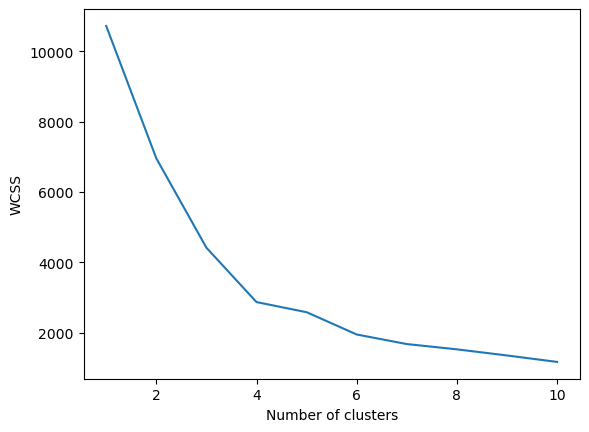

In [374]:
# Determine Optimal Number of Clusters
# Method : Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(rfm_product_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

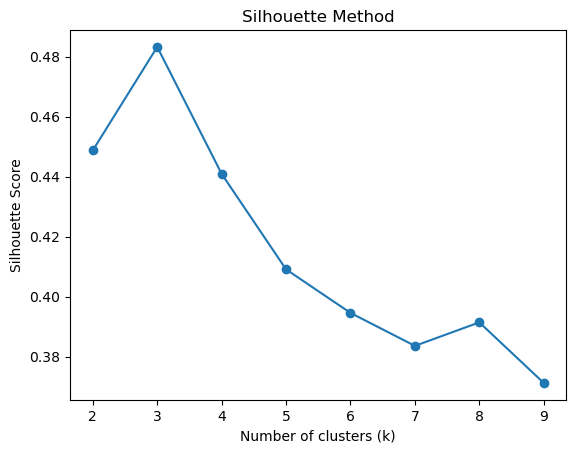

In [375]:
# Silhouette score (to justify the choice)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X = rfm_product_scaled  # your scaled RFM data

silhouette_scores = []

k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Plot
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()

# The optimal number of clusters = 3

#### The Optimal number of clusters = 3

- Apply K-Means clustering to segment the demand and assign each one to a cluster.


In [376]:
# Train the Clustering Model - K-Means

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(rfm_product_scaled)

rfm_product['Cluster'] = clusters
rfm_product

,Recency,Frequency,Monetary,Cluster
Description,,,,
4 PURPLE FLOCK DINNER CANDLES,1,6,265.66,0
50'S CHRISTMAS GIFT BAG LARGE,0,11,1601.25,0
DOLLY GIRL BEAKER,0,9,1182.50,0
I LOVE LONDON MINI BACKPACK,1,8,908.85,0
I LOVE LONDON MINI RUCKSACK,64,1,4.15,0
...,...,...,...,...
ZINC T-LIGHT HOLDER STARS LARGE,144,1,22.80,1
ZINC T-LIGHT HOLDER STARS SMALL,0,11,2248.70,0
ZINC WILLIE WINKIE CANDLE STICK,0,11,1726.22,0


- Reduce the dimensionality of the dataset and visualize customer clusters in a 2D space.

(3575, 2)


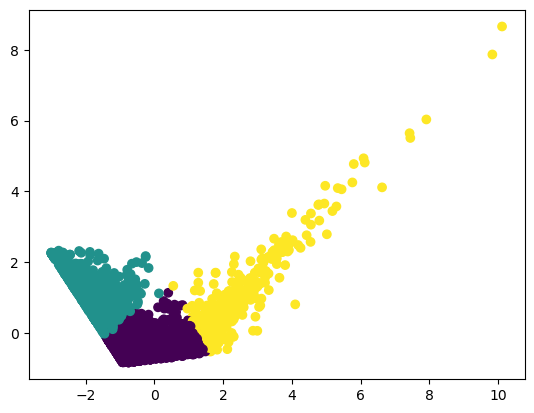

In [382]:
# Cluster Visualization
# Using PCA (dimensionality reduction)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_product = PCA(n_components=2)
rfm_product_pca = pca_product.fit_transform(rfm_product_scaled)
print(rfm_product_pca.shape)
      
plt.scatter(rfm_product_pca[:,0], rfm_product_pca[:,1], c=rfm_product["Cluster"], cmap='viridis')
plt.show()


In [378]:
# Cluster Profiling (Most Important Step)
# Understand what each cluster represents.

cluster_profile = rfm_product.groupby('Cluster').mean()
print(cluster_profile)

            Recency  Frequency     Monetary
Cluster                                    
0         15.176970   6.686061   667.327525
1        231.436335   3.310559   138.631444
2          3.607456  13.164474  5610.881382


Business Interpretation:

Cluster 2 — “High-demand / Fast-moving items”

Cluster 0 — “Steady / Mid-tier demand items”

Cluster 1 — “Low-demand / Slow-moving items”

#

### -  The aim of this code is to analyze the most common product-related words associated with customers in Cluster 2.


In [379]:
cluster_2 = rfm_product[rfm_product["Cluster"] == 2]
cluster_2_products = []
for index, row in cluster_2.iterrows():
    cluster_2_products.append(index)

from collections import Counter

# Combine all words
all_words = []
for desc in cluster_2_products:
    words = desc.upper().split()  # split by space, convert to uppercase
    all_words.extend(words)

# Count frequency
word_counts = Counter(all_words)

# Show top 50 common words
print(word_counts.most_common(50))

[('BAG', 55), ('OF', 51), ('SET', 49), ('HEART', 45), ('RETROSPOT', 39), ('RED', 38), ('CHRISTMAS', 33), ('VINTAGE', 32), ('DESIGN', 31), ('PINK', 26), ('JUMBO', 25), ('METAL', 24), ('BOX', 22), ('SIGN', 20), ('WHITE', 20), ('LUNCH', 20), ('WOODEN', 19), ('SMALL', 17), ('CAKE', 17), ('TEA', 16), ('6', 16), ('PAPER', 16), ('3', 15), ('FELTCRAFT', 15), ('HOT', 15), ('DECORATION', 14), ('WATER', 14), ('BOTTLE', 14), ('HANGING', 13), ('BLUE', 12), ('IN', 12), ('POLKADOT', 12), ('PACK', 12), ('WICKER', 12), ('PANTRY', 12), ('CASES', 11), ('T-LIGHT', 11), ('CERAMIC', 11), ('BUNTING', 10), ('DRAWER', 10), ('CHILDRENS', 10), ('HOLDER', 10), ('LOVE', 9), ('TRADITIONAL', 9), ('CUTLERY', 9), ('LARGE', 9), ('KIT', 9), ('REGENCY', 9), ('HAND', 9), ('PAISLEY', 9)]


#### Cluster 2 is heavily focused on functional everyday items, especially:

    - Storage (boxes, bags)
    - Kitchen & dining (cutlery, lunch items, bottles)
    - Giftable sets
    
These are practical, repeat-purchase products, which aligns well with high-frequency buying behavior.

#
### - The aim of this code is to analyze the most common product-related words associated with customers in Cluster 0.

In [380]:
cluster_0 = rfm_product[rfm_product["Cluster"] == 0]
cluster_0_products = []
for index, row in cluster_0.iterrows():
    cluster_0_products.append(index)

from collections import Counter

# Combine all words
all_words_0 = []
for desc in cluster_0_products:
    words_0 = desc.upper().split()  # split by space, convert to uppercase
    all_words_0.extend(words_0)

# Count frequency
word_counts_0 = Counter(all_words_0)

# Show top 50 common words
print(word_counts_0.most_common(50))

[('SET', 173), ('PINK', 165), ('OF', 158), ('HEART', 142), ('VINTAGE', 130), ('BLUE', 130), ('RED', 116), ('CHRISTMAS', 91), ('HOLDER', 86), ('BOX', 84), ('SMALL', 77), ('CANDLE', 76), ('DESIGN', 74), ('DECORATION', 74), ('BAG', 73), ('WALL', 73), ('WHITE', 70), ('FLOWER', 70), ('ART', 68), ('HANGING', 67), ('ROSE', 66), ('GLASS', 66), ('T-LIGHT', 66), ('GREEN', 65), ('LARGE', 63), ('CARD', 62), ('SILVER', 61), ('BLACK', 60), ('METAL', 60), ('PAPER', 55), ('4', 54), ('WRAP', 53), ('MINI', 50), ('MUG', 50), ('COVER', 49), ('RETROSPOT', 48), ('WITH', 48), ('AND', 48), ('PACK', 47), ('ASSORTED', 46), ('12', 45), ('CAKE', 44), ('STAR', 44), ('RING', 44), ('GIFT', 43), ('3', 43), ('6', 43), ('LOVE', 41), ('IN', 41), ('GARDEN', 41)]



#### Cluster 0 is heavily focused on decorative and gift-oriented items, especially:

	- Functional items (bags, mugs, boxes)
	- Gift-related packaging (wrap, paper)



#
### - The aim of this code is to analyze the most common product-related words associated with customers in Cluster 1.

In [381]:
cluster_1 = rfm_product[rfm_product["Cluster"] == 1]
cluster_1_products = []
for index, row in cluster_1.iterrows():
    cluster_1_products.append(index)

from collections import Counter

# Combine all words
all_words_1 = []
for desc in cluster_1_products:
    words_1 = desc.upper().split()  # split by space, convert to uppercase
    all_words_1.extend(words_1)

# Count frequency
word_counts_1 = Counter(all_words_1)

# Show top 50 common words
print(word_counts_1.most_common(50))

[('PINK', 83), ('BLUE', 55), ('GLASS', 53), ('HEART', 38), ('SET', 32), ('FLOWER', 31), ('VINTAGE', 30), ('WHITE', 29), ('BAG', 27), ('RED', 24), ('ROSE', 23), ('BRACELET', 23), ('LARGE', 20), ('POLKADOT', 20), ('EASTER', 20), ('GARDEN', 20), ('CHRISTMAS', 19), ('WITH', 19), ('METAL', 19), ('OF', 18), ('BLACK', 18), ('W', 18), ('HOLDER', 18), ('3', 17), ('SMALL', 17), ('DESIGN', 17), ('GREEN', 17), ('IN', 16), ('AND', 16), ('HANGING', 16), ('EARRINGS', 15), ('COVER', 15), ('CANDLE', 14), ('GOLD', 14), ('MUG', 14), ('EGG', 14), ('FLOCK', 13), ('FELT', 13), ('SILVER', 12), ('BEAD', 12), ('NECKLACE', 12), ('BOWL', 12), ('PAPER', 12), ('T-LIGHT', 12), ('MIRROR', 11), ('CHARM', 11), ('CUSHION', 11), ('SHELL', 11), ('CAKE', 10), ('BOX', 10)]


#### Cluster 1 is heavily focused on products designed for gifting or special occasions, appealing to emotional value. especially:

	- Home decor items (ambient lighting, mirror, cushion)
	- Accessories (jewelry items like bracelets, necklaces, and earrings)